<a href="https://colab.research.google.com/github/hassen8/emotion_recognition_bias_auditing/blob/master/DeepFace_EmotiEffLib_Qualitative_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Install Dependencies

In [ ]:
!pip -q install emotiefflib[torch] deepface opencv-python tqdm pandas matplotlib scikit-image lime grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 79.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.2/169.2 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.0/170.0 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip -q uninstall -y pillow
!pip -q install pillow==10.2.0

# Imports

In [ ]:
import os, json, re
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision.transforms as T

from tqdm import tqdm
from PIL import Image

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import top_k_accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from emotiefflib.facial_analysis import EmotiEffLibRecognizer
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

np.random.seed(0)
torch.manual_seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


# Dataset

In [ ]:
ZIP_PATH   = "/content/drive/MyDrive/Image/aligned.zip"
LABEL_PATH = "/content/drive/MyDrive/EmoLabel/list_patition_label.txt"

!unzip -oq "{ZIP_PATH}" -d /content
!cp "{LABEL_PATH}" /content/list_patition_label.txt

IMAGE_DIR  = Path("/content/aligned")
LABEL_FILE = Path("/content/list_patition_label.txt")

print("IMAGE_DIR:", IMAGE_DIR, "exists:", IMAGE_DIR.exists())
print("LABEL_FILE:", LABEL_FILE, "exists:", LABEL_FILE.exists())


IMAGE_DIR: /content/aligned exists: True
LABEL_FILE: /content/list_patition_label.txt exists: True


# Canonical Labels

In [ ]:
# Canonical 7-class emotion order (use this everywhere)
EMOTIONS = ["angry", "disgust", "fear", "happy", "sad", "surprise", "neutral"]
E2I = {e:i for i,e in enumerate(EMOTIONS)}

# RAF-DB numeric IDs (typical RAF labels: 1..7)
RAF_ID_TO_EMO = {
    1: "surprise",
    2: "fear",
    3: "disgust",
    4: "happy",
    5: "sad",
    6: "angry",
    7: "neutral",
}

# Colab device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Output root
OUT_ROOT = Path("/content/protocolA_outputs")
OUT_ROOT.mkdir(parents=True, exist_ok=True)


device: cuda


# Plotting Functions

In [ ]:
def clean_title(gt, pred, conf=None):
    gt_s = "NA" if gt is None or (isinstance(gt, float) and np.isnan(gt)) else str(gt)
    pr_s = "NA" if pred is None else str(pred)
    if conf is None:
        return f"GT: {gt_s} | Pred: {pr_s}"
    return f"GT: {gt_s} | Pred: {pr_s} | Conf: {conf:.3f}"

def show_rgb(img, title=None, figsize=(4,4)):
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

def overlay_heatmap_on_rgb(rgb_uint8, heat01, alpha=0.45):
    """
    heat01: (H,W) float in [0,1]
    returns: overlay RGB uint8 + heatmap uint8
    """
    H, W = rgb_uint8.shape[:2]
    heat = np.clip(heat01, 0, 1)
    heat_u8 = (heat * 255).astype(np.uint8)
    heat_color = cv2.applyColorMap(heat_u8, cv2.COLORMAP_JET)  # BGR
    heat_color = cv2.cvtColor(heat_color, cv2.COLOR_BGR2RGB)
    overlay = (alpha * heat_color + (1 - alpha) * rgb_uint8).astype(np.uint8)
    return overlay, heat_u8

In [ ]:
def read_rgb_uint8(path):
    img_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    if img_rgb.dtype != np.uint8:
        img_rgb = np.clip(img_rgb, 0, 255).astype(np.uint8)
    return img_rgb

# Face crop function

In [ ]:
from deepface import DeepFace

def get_shared_face_crop(rgb_uint8, detector_backend="retinaface", target_size=None):
    """
    Returns a face crop (RGB uint8). If detection fails, returns original image.
    target_size: optional (w,h) resize of the crop for display consistency only.
    """
    try:
        # DeepFace expects BGR in some utilities; extract_faces accepts numpy arrays
        # We'll pass as BGR to be safe:
        bgr = cv2.cvtColor(rgb_uint8, cv2.COLOR_RGB2BGR)

        faces = DeepFace.extract_faces(
            img_path=bgr,
            detector_backend=detector_backend,
            enforce_detection=False,
            align=True
        )
        # faces is list of dicts
        if faces and "face" in faces[0]:
            face_bgr = faces[0]["face"]  # usually float 0..1
            if face_bgr.dtype != np.uint8:
                face_bgr = np.clip(face_bgr * 255.0, 0, 255).astype(np.uint8)
            face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)
        else:
            face_rgb = rgb_uint8
    except Exception:
        face_rgb = rgb_uint8

    if target_size is not None:
        w, h = target_size
        face_rgb = cv2.resize(face_rgb, (w, h), interpolation=cv2.INTER_CUBIC)

    return face_rgb


26-02-06 12:58:51 - Directory /root/.deepface has been created
26-02-06 12:58:51 - Directory /root/.deepface/weights has been created


# Load dataset

In [ ]:
def load_raf_df(image_dir: Path, label_file: Path, split: str):
    df = pd.read_csv(label_file, sep=" ", header=None, names=["file_name", "label"])

    if split == "train":
        df = df[df["file_name"].str.startswith("train")]
    elif split == "test":
        df = df[df["file_name"].str.startswith("test")]
    else:
        raise ValueError("split must be 'train' or 'test'")

    df["aligned_name"] = df["file_name"].str.replace(".jpg", "_aligned.jpg", regex=False)
    df["file_path"] = df["aligned_name"].apply(lambda x: str(image_dir / x))

    df["emotion_label"] = df["label"].map(RAF_ID_TO_EMO)
    df["split"] = split

    df = df[df["file_path"].apply(os.path.exists)].reset_index(drop=True)

    # hard fail if mapping breaks
    if df["emotion_label"].isna().any():
        bad = df[df["emotion_label"].isna()].head(10)
        raise RuntimeError(f"Some labels could not be mapped. Example rows:\n{bad}")

    # return BOTH numeric + string GT + filenames for clean outputs
    return df[["file_path", "file_name", "label", "emotion_label", "split"]]

In [ ]:
df_train = load_raf_df(IMAGE_DIR, LABEL_FILE, "train")
df_test  = load_raf_df(IMAGE_DIR, LABEL_FILE, "test")
df = pd.concat([df_train, df_test], ignore_index=True)

print("Rows:", len(df))
print(df["split"].value_counts(), "\n")
print(df["emotion_label"].value_counts())
df.head()

Rows: 15339
split
train    12271
test      3068
Name: count, dtype: int64 

emotion_label
happy       5957
neutral     3204
sad         2460
surprise    1619
disgust      877
angry        867
fear         355
Name: count, dtype: int64


,file_path,file_name,label,emotion_label,split
0,/content/aligned/train_00001_aligned.jpg,train_00001.jpg,5,sad,train
1,/content/aligned/train_00002_aligned.jpg,train_00002.jpg,5,sad,train
2,/content/aligned/train_00003_aligned.jpg,train_00003.jpg,4,happy,train
3,/content/aligned/train_00004_aligned.jpg,train_00004.jpg,4,happy,train
4,/content/aligned/train_00005_aligned.jpg,train_00005.jpg,5,sad,train


In [ ]:
df_eval = df[df["split"] == "test"].reset_index(drop=True)
print("df_eval:", len(df_eval))
print(df_eval["emotion_label"].value_counts())

df_eval: 3068
emotion_label
happy       1185
neutral      680
sad          478
surprise     329
angry        162
disgust      160
fear          74
Name: count, dtype: int64


In [ ]:
def pick_examples_per_class(df_in, k=1, seed=42):
    rng = np.random.default_rng(seed)
    idxs = []
    for emo in EMOTIONS:
        sub = df_in[df_in["emotion_label"] == emo]
        if len(sub) == 0:
            continue
        pick = rng.choice(sub.index.values, size=min(k, len(sub)), replace=False)
        idxs.extend(pick.tolist())
    return sorted(idxs)

SAMPLE_IDXS = pick_examples_per_class(df_eval, k=1, seed=42)
print("Samples:", len(SAMPLE_IDXS))

Samples: 7


# Model Runners

## **EmotiEffLib model load**

In [ ]:
from emotiefflib.facial_analysis import EmotiEffLibRecognizer

MODEL_NAME = "enet_b2_7"
recognizer = EmotiEffLibRecognizer(engine="torch", model_name=MODEL_NAME, device=device)

In [ ]:
def get_emotieff_class_names(recognizer):

    for attr in ["emotions", "classes", "class_names", "labels"]:
        if hasattr(recognizer, attr):
            v = getattr(recognizer, attr)
            if isinstance(v, (list, tuple)) and len(v) == 7:
                return [str(x).lower() for x in v]
    return EMOTIONS

EMOTIEFF_CLASSES = get_emotieff_class_names(recognizer)

reorder_idx = []
for e in EMOTIONS:
    if e not in EMOTIEFF_CLASSES:
        raise RuntimeError(f"EmotiEffLib classes missing '{e}'. Found: {EMOTIEFF_CLASSES}")
    reorder_idx.append(EMOTIEFF_CLASSES.index(e))

print("EmotiEffLib class order:", EMOTIEFF_CLASSES)
print("reorder_idx (EMOTIONS <- EMOTIEFF_CLASSES):", reorder_idx)


EmotiEffLib class order: ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
reorder_idx (EMOTIONS <- EMOTIEFF_CLASSES): [0, 1, 2, 3, 4, 5, 6]


In [ ]:
def emotieff_predict_proba(rgb_uint8):
    pred_label_str, logits = recognizer.predict_emotions([rgb_uint8], logits=True)
    logits_native = np.asarray(logits[0], dtype=np.float32).reshape(-1)
    if logits_native.shape[0] != 7:
        raise RuntimeError(f"Expected 7 logits, got {logits_native.shape[0]}")

    # softmax
    ex = np.exp(logits_native - logits_native.max())
    probs_native = ex / (ex.sum() + 1e-12)

    # reorder to canonical EMOTIONS
    probs7 = probs_native[reorder_idx].astype(np.float32)
    pred_idx = int(np.argmax(probs7))
    pred = EMOTIONS[pred_idx]
    conf = float(probs7[pred_idx])
    return probs7, pred, conf

## **DeepFace Model load**

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
from deepface import DeepFace

_df_obj = DeepFace.build_model(task="facial_attribute", model_name="Emotion")

# Extract the actual keras model safely
def _unwrap_keras_model(obj):
    #
    if isinstance(obj, tf.keras.Model):
        return obj

    # wrapper objects to expose .model
    if hasattr(obj, "model") and isinstance(getattr(obj, "model"), tf.keras.Model):
        return getattr(obj, "model")

    if hasattr(obj, "models"):
        m = getattr(obj, "models")
        if isinstance(m, dict):
            # try any keras model in it
            for v in m.values():
                if isinstance(v, tf.keras.Model):
                    return v

    raise TypeError(f"Could not unwrap a tf.keras.Model from DeepFace object of type: {type(obj)}")

deepface_emotion_model = _unwrap_keras_model(_df_obj)
deepface_emotion_model.trainable = False
print("DeepFace emotion keras model:", type(deepface_emotion_model), "| name:", deepface_emotion_model.name)

# DeepFace emotion class order
DEEPFACE_CLASSES = ["angry","disgust","fear","happy","sad","surprise","neutral"]
df_reorder = [DEEPFACE_CLASSES.index(e) for e in EMOTIONS]

def preprocess_deepface_emotion(rgb_uint8):
    gray = cv2.cvtColor(rgb_uint8, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, (48, 48), interpolation=cv2.INTER_AREA)
    x = gray.astype(np.float32) / 255.0
    x = x.reshape(1, 48, 48, 1)
    return x

def deepface_predict_proba(rgb_uint8):
    x = preprocess_deepface_emotion(rgb_uint8)
    probs_native = deepface_emotion_model.predict(x, verbose=0)[0].astype(np.float32)
    probs_native = probs_native / (probs_native.sum() + 1e-12)
    probs7 = probs_native[df_reorder]
    pred_idx = int(np.argmax(probs7))
    pred = EMOTIONS[pred_idx]
    conf = float(probs7[pred_idx])
    return probs7, pred, conf

DeepFace emotion keras model: <class 'keras.src.models.sequential.Sequential'> | name: sequential


## Sanity check

In [ ]:
def sanity_check_predictions(preds, probs):
    preds = np.array(preds, dtype=object)
    probs = np.asarray(probs, dtype=np.float32)

    valid = np.array([p is not None for p in preds])
    if valid.sum() == 0:
        print("No valid predictions - pipeline broken.")
        return

    P = probs[valid]
    y = preds[valid]

    vc = pd.Series(y).value_counts(normalize=True).reindex(EMOTIONS).fillna(0)
    print("Pred distribution:")
    for e in EMOTIONS:
        print(f"  {e:>8}: {vc[e]*100:6.2f}%")

    conf = P.max(axis=1)
    ent = -(P * np.log(P + 1e-12)).sum(axis=1)
    print(f"\nMean top-1 conf: {conf.mean():.3f} | Std: {conf.std():.3f}")
    print(f"Mean entropy:   {ent.mean():.3f} | Std: {ent.std():.3f}")
    print("Uniform-ish baseline entropy for 7 classes ~ 1.946. If it's near that: then it is basically random.")


In [ ]:
def eval_model_on_indices(df, idxs, runner_predict):
    preds, probs, gts, paths, faces = [], [], [], [], []
    for i in tqdm(idxs):
        p = df.loc[i, "file_path"]
        gt = df.loc[i, "emotion_label"]

        rgb = read_rgb_uint8(p)
        if rgb is None:
            preds.append(None)
            probs.append(np.ones(7, dtype=np.float32)/7)
            gts.append(gt)
            paths.append(p)
            faces.append(None)
            continue

        face = get_shared_face_crop(rgb, detector_backend="retinaface")
        pr, pred, conf = runner_predict(face)

        preds.append(pred)
        probs.append(pr)
        gts.append(gt)
        paths.append(p)
        faces.append(face)

    return {
        "preds": preds,
        "probs": np.vstack(probs),
        "gts": gts,
        "paths": paths,
        "faces": faces
    }

emotieff_eval = eval_model_on_indices(df_eval, SAMPLE_IDXS, emotieff_predict_proba)
deepface_eval = eval_model_on_indices(df_eval, SAMPLE_IDXS, deepface_predict_proba)

print("\n=== EmotiEffLib sanity ===")
sanity_check_predictions(emotieff_eval["preds"], emotieff_eval["probs"])

print("\n=== DeepFace sanity ===")
sanity_check_predictions(deepface_eval["preds"], deepface_eval["probs"])


100%|██████████| 7/7 [00:06<00:00,  1.13it/s]


=== EmotiEffLib sanity ===
Pred distribution:
     angry:  14.29%
   disgust:  14.29%
      fear:   0.00%
     happy:  14.29%
       sad:  14.29%
  surprise:  14.29%
   neutral:  28.57%

Mean top-1 conf: 0.691 | Std: 0.193
Mean entropy:   0.798 | Std: 0.443
Uniform-ish baseline entropy for 7 classes ~ 1.946. If it's near that: then it is basically random.

=== DeepFace sanity ===
Pred distribution:
     angry:   0.00%
   disgust:  14.29%
      fear:  14.29%
     happy:  28.57%
       sad:  14.29%
  surprise:  14.29%
   neutral:  14.29%

Mean top-1 conf: 0.877 | Std: 0.139
Mean entropy:   0.361 | Std: 0.336
Uniform-ish baseline entropy for 7 classes ~ 1.946. If it's near that: then it is basically random.


In [ ]:
p_disgust = deepface_eval["probs"][:, E2I["disgust"]]
print("DeepFace disgust prob stats:")
print("  mean:", float(p_disgust.mean()))
print("  max :", float(p_disgust.max()))
print("  top 5:", np.sort(p_disgust)[-5:])


DeepFace disgust prob stats:
  mean: 0.14042796194553375
  max : 0.9829900860786438
  top 5: [1.32506806e-08 9.88068905e-07 1.30238573e-06 3.31364276e-06
 9.82990086e-01]


# GRAD-CAM

### Grad-CAM on DeepFace Emotion Model

Given a CNN and a target class $c$ (e.g., "happy"), Grad-CAM operates on the **last
convolutional feature maps** $A^k$ (where $k$ indexes channels) and the class
score $y^c$ (the logit or pre-softmax value for class $c$).

Formally, let the preprocessed input be
$$
x \in \mathbb{R}^{1 \times 48 \times 48 \times 1}.
$$

1. **Forward pass**

   We run a forward pass through `gradcam_model` to obtain:

   - $A^k$: feature maps from the last convolutional layer
   - $y^c$: class scores for all emotion classes

2. **Select target class**

   We choose the target class $c$ either as:
   - the predicted class $c = \arg\max y$, or  
   - a manually specified class index.

3. **Gradients w.r.t. feature maps**

   Using automatic differentiation (`tf.GradientTape`), we compute the gradient
   of the target class score with respect to each feature map:

   $$
   \frac{\partial y^c}{\partial A^k_{ij}} \, .
   $$

4. **Channel importance weights**

   We spatially average these gradients over the feature map to obtain a single
   **importance weight** $\alpha_k^c$ per channel:

   $$
   \alpha_k^c = \frac{1}{Z} \sum_i \sum_j \frac{\partial y^c}{\partial A^k_{ij}}
   $$

   where $Z$ is the number of spatial locations (height $\times$ width).

5. **Grad-CAM map**

   We then form the Grad-CAM map as a weighted sum of the feature maps,
   followed by a ReLU to keep only positive contributions:

   $$
   L_{\text{Grad-CAM}}^c = \mathrm{ReLU}\left( \sum_k \alpha_k^c A^k \right).
   $$

6. **Normalization and upsampling**

   Finally, we normalize $L_{\text{Grad-CAM}}^c$ to the range $[0,1]$ and
   upsample it to the original image resolution to obtain a **heatmap**
   showing which pixels contribute most to class $c$.

In our project, we apply this procedure to a subset of RAF-DB samples to inspect how
DeepFace’s internal attention patterns relate to facial regions (eyes, mouth, etc.)
and to known differences in neurodivergent expression (e.g., reduced eye contact,
flatter affect).


## Visualizing Grad-CAM on RAF images

We now apply Grad-CAM to RAF-DB samples. For each image:

1. We load the pre-aligned BGR face from RAF-DB.
2. We preprocess it to (1, 48, 48, 1) for the emotion model.
3. We compute the Grad-CAM heatmap.
4. We upsample the heatmap to the original image size and overlay it
   with a color map to highlight important regions.

This gives a qualitative view of which facial regions (eyes, mouth, nose etc.)
the model uses to classify different emotions.

## EmotiEffLib

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def unwrap_torch_model(recognizer):
    for attr in ["model", "net", "backbone", "_model"]:
        if hasattr(recognizer, attr):
            m = getattr(recognizer, attr)
            if isinstance(m, nn.Module):
                return m
    for _, v in recognizer.__dict__.items():
        if isinstance(v, nn.Module):
            return v
    raise RuntimeError("Could not find torch.nn.Module inside recognizer.")

torch_model = unwrap_torch_model(recognizer).to(device).eval()

def pick_best_cam_layer(model: nn.Module, input_size=224):
    model.eval()
    x = torch.zeros(1, 3, input_size, input_size, device=next(model.parameters()).device)

    conv_layers = []
    hooks = []

    def hook_fn(m, inp, out):
        if isinstance(out, torch.Tensor) and out.ndim == 4:
            H, W = out.shape[-2], out.shape[-1]
            conv_layers.append((m, int(H), int(W)))

    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            hooks.append(m.register_forward_hook(hook_fn))

    with torch.no_grad():
        _ = model(x)

    for h in hooks:
        h.remove()

    for m, H, W in reversed(conv_layers):
        if H >= 7 and W >= 7:
            return m
    return conv_layers[-1][0]

target_layer_emotieff = pick_best_cam_layer(torch_model, input_size=224)
print("EmotiEffLib Grad-CAM target layer:", target_layer_emotieff)

def to_torch_tensor(rgb_uint8, size=224):
    img = cv2.resize(rgb_uint8, (size, size), interpolation=cv2.INTER_CUBIC)
    x = img.astype(np.float32) / 255.0
    x = np.transpose(x, (2,0,1))[None, ...]  # (1,3,H,W)
    return torch.tensor(x, device=device)

def emotieff_gradcam(face_rgb_uint8, alpha=0.45, size=224):
    probs7, pred, conf = emotieff_predict_proba(face_rgb_uint8)
    target_idx = int(np.argmax(probs7))

    x = to_torch_tensor(face_rgb_uint8, size=size)

    cam = GradCAM(model=torch_model, target_layers=[target_layer_emotieff])
    cam_map = cam(input_tensor=x, targets=[ClassifierOutputTarget(target_idx)])[0].astype(np.float32)

    H, W = face_rgb_uint8.shape[:2]
    cam_resized = cv2.resize(cam_map, (W, H), interpolation=cv2.INTER_CUBIC)
    cam_resized = np.maximum(cam_resized, 0)
    cam_resized = (cam_resized - cam_resized.min()) / (cam_resized.max() - cam_resized.min() + 1e-8)

    overlay, heat_u8 = overlay_heatmap_on_rgb(face_rgb_uint8, cam_resized, alpha=alpha)
    return cam_resized, overlay, heat_u8, pred, conf


EmotiEffLib Grad-CAM target layer: Conv2d(352, 1408, kernel_size=(1, 1), stride=(1, 1), bias=False)


## DeepFace

In [ ]:
from tensorflow.keras.layers import Conv2D, DepthwiseConv2D, SeparableConv2D
import tensorflow as tf

def find_last_conv_layer_keras(model):
    conv_types = (Conv2D, DepthwiseConv2D, SeparableConv2D)
    last = None

    def walk(m):
        nonlocal last
        for layer in getattr(m, "layers", []):
            if isinstance(layer, tf.keras.Model):
                walk(layer)
            if isinstance(layer, conv_types):
                last = layer

    walk(model)

    if last is None:
        raise RuntimeError("No Conv2D-like layer found in DeepFace emotion model.")
    return last

last_conv = find_last_conv_layer_keras(deepface_emotion_model)
print("DeepFace target conv:", last_conv.name, "| output:", last_conv.output.shape)

DeepFace target conv: conv2d_4 | output: (None, 3, 3, 128)


In [ ]:
import tensorflow as tf

# Make a fresh functional graph by explicitly chaining the Sequential layers
inputs = tf.keras.Input(shape=(48, 48, 1), name="df_input")

x = inputs
conv_out = None

for layer in deepface_emotion_model.layers:
    x = layer(x)
    if layer.name == last_conv.name:
        conv_out = x

preds = x  # final logits/probs from the emotion model

if conv_out is None:
    raise RuntimeError(f"Could not capture conv output for layer: {last_conv.name}")

# build the gradcam model from this new graph
gradcam_model = tf.keras.Model(inputs=inputs, outputs=[conv_out, preds], name="df_gradcam_model")

_dummy = tf.zeros((1, 48, 48, 1), dtype=tf.float32)
co, pr = gradcam_model(_dummy, training=False)
print("Grad-CAM model ready. conv_out:", co.shape, "| preds:", pr.shape)


Grad-CAM model ready. conv_out: (1, 3, 3, 128) | preds: (1, 7)


In [ ]:
def deepface_gradcam(face_rgb_uint8, alpha=0.45):
    probs7, pred, conf = deepface_predict_proba(face_rgb_uint8)
    target_idx = int(np.argmax(probs7))

    x = preprocess_deepface_emotion(face_rgb_uint8)

    with tf.GradientTape() as tape:
        conv_out, preds = gradcam_model(x, training=False)
        native_target = df_reorder[target_idx]
        loss = preds[:, native_target]

    grads = tape.gradient(loss, conv_out)
    if grads is None:
        raise RuntimeError("Grad-CAM grads are None.")

    weights = tf.reduce_mean(grads, axis=(1, 2))
    cam = tf.reduce_sum(conv_out * weights[:, None, None, :], axis=-1)[0].numpy()

    cam = np.maximum(cam, 0)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    H, W = face_rgb_uint8.shape[:2]
    cam_resized = cv2.resize(cam.astype(np.float32), (W, H), interpolation=cv2.INTER_CUBIC)
    cam_resized = np.clip(cam_resized, 0, 1)

    overlay, heat_u8 = overlay_heatmap_on_rgb(face_rgb_uint8, cam_resized, alpha=alpha)
    return cam_resized, overlay, heat_u8, pred, conf



---



---



# **OCCLUSION**

In [ ]:
def occlusion_map(face_rgb_uint8, score_fn, target_idx=None, patch_frac=0.12, stride_frac=0.06):
    """
    score_fn(face_rgb_uint8)-> probs7
    returns heat01 same size as face.
    """
    H, W = face_rgb_uint8.shape[:2]
    patch = max(8, int(min(H, W) * patch_frac))
    stride = max(4, int(min(H, W) * stride_frac))

    base_probs = score_fn(face_rgb_uint8)
    if target_idx is None:
        target_idx = int(np.argmax(base_probs))
    base_score = float(base_probs[target_idx])

    heat = np.zeros((H, W), dtype=np.float32)
    count = np.zeros((H, W), dtype=np.float32)

    for y in range(0, H - patch + 1, stride):
        for x in range(0, W - patch + 1, stride):
            occluded = face_rgb_uint8.copy()
            occluded[y:y+patch, x:x+patch, :] = 0  # black patch
            p = score_fn(occluded)
            s = float(p[target_idx])
            drop = base_score - s  # positive means region important
            heat[y:y+patch, x:x+patch] += drop
            count[y:y+patch, x:x+patch] += 1.0

    heat = heat / (count + 1e-8)
    heat = np.maximum(heat, 0)
    heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
    return heat

def emotieff_score(face_rgb_uint8):
    return emotieff_predict_proba(face_rgb_uint8)[0]

def deepface_score(face_rgb_uint8):
    return deepface_predict_proba(face_rgb_uint8)[0]



---



---



# **LIME**

## Lime wrapper per model

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
from skimage.util import img_as_ubyte

def emotieff_predict_proba_lime(images):
    out = np.zeros((len(images), 7), dtype=np.float32)
    for i, img_rgb in enumerate(images):
        if img_rgb.dtype != np.uint8:
            img_rgb = np.clip(img_rgb, 0, 255).astype(np.uint8)
        try:
            out[i] = emotieff_score(img_rgb)
        except Exception:
            out[i] = 1.0/7
    return out

def deepface_predict_proba_lime(images):
    out = np.zeros((len(images), 7), dtype=np.float32)
    for i, img_rgb in enumerate(images):
        if img_rgb.dtype != np.uint8:
            img_rgb = np.clip(img_rgb, 0, 255).astype(np.uint8)
        try:
            out[i] = deepface_score(img_rgb)
        except Exception:
            out[i] = 1.0/7
    return out

def lime_explain(face_rgb_uint8, classifier_fn, target_idx=None, n_samples=1000, num_features=8):
    explainer = lime_image.LimeImageExplainer()

    probs = classifier_fn([face_rgb_uint8])[0]
    if target_idx is None:
        target_idx = int(np.argmax(probs))

    explanation = explainer.explain_instance(
        face_rgb_uint8,
        classifier_fn=classifier_fn,
        top_labels=7,
        hide_color=0,
        num_samples=n_samples,
        segmentation_fn=lambda x: slic(x, n_segments=120, compactness=10, sigma=1)
    )

    temp, mask = explanation.get_image_and_mask(
        label=target_idx,
        positive_only=True,
        num_features=num_features,
        hide_rest=False
    )

    # convert mask to heat01 for consistent overlay
    mask01 = (mask > 0).astype(np.float32)
    overlay, heat_u8 = overlay_heatmap_on_rgb(face_rgb_uint8, mask01, alpha=0.35)
    return mask01, overlay, heat_u8


# Generate Grids per model

## Save Utilities + grid generator

In [ ]:
def ensure_dirs(root: Path):
    for sub in ["gradcam", "occlusion", "lime", "grids"]:
        (root/sub).mkdir(parents=True, exist_ok=True)

def save_rgb(path, rgb):
    path.parent.mkdir(parents=True, exist_ok=True)
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(path), bgr)

def make_row(face, gt, pred, conf, cam_overlay, occ_overlay, lime_overlay, title_prefix=""):
    fig = plt.figure(figsize=(14,4))
    axs = [plt.subplot(1,4,i+1) for i in range(4)]

    axs[0].imshow(face);        axs[0].axis("off"); axs[0].set_title(title_prefix + "Face\n" + clean_title(gt,pred,conf))
    axs[1].imshow(cam_overlay); axs[1].axis("off"); axs[1].set_title("Grad-CAM")
    axs[2].imshow(occ_overlay); axs[2].axis("off"); axs[2].set_title("Occlusion")
    axs[3].imshow(lime_overlay);axs[3].axis("off"); axs[3].set_title("LIME")
    plt.tight_layout()
    return fig

def run_suite_for_model(model_name, df, idxs, eval_pack, gradcam_fn, score_fn, lime_fn, out_root: Path):
    root = out_root / model_name
    ensure_dirs(root)

    for j, idx in enumerate(idxs):
        face = eval_pack["faces"][j]
        if face is None:
            continue

        gt = eval_pack["gts"][j]
        probs7 = eval_pack["probs"][j]
        pred = eval_pack["preds"][j]
        conf = float(np.max(probs7))

        stem = Path(df.loc[idx, "file_name"]).stem
        base_name = f"{j:03d}_{stem}_GT-{gt}_PRED-{pred}_CONF-{conf:.2f}"

        # Grad-CAM
        cam01, cam_overlay, _, _, _ = gradcam_fn(face)

        # Occlusion
        target_idx = int(np.argmax(probs7))
        occ01 = occlusion_map(face, score_fn=score_fn, target_idx=target_idx)
        occ_overlay, _ = overlay_heatmap_on_rgb(face, occ01, alpha=0.45)

        # LIME
        lime01, lime_overlay, _ = lime_fn(face, target_idx=target_idx)

        # Save individual
        save_rgb(root/"gradcam"/f"{base_name}.png", cam_overlay)
        save_rgb(root/"occlusion"/f"{base_name}.png", occ_overlay)
        save_rgb(root/"lime"/f"{base_name}.png", lime_overlay)

        # Save row grid
        fig = make_row(face, gt, pred, conf, cam_overlay, occ_overlay, lime_overlay)
        grid_path = root/"grids"/f"{base_name}_GRID.png"
        fig.savefig(str(grid_path), dpi=160, bbox_inches="tight")
        plt.close(fig)

    print(f"Saved outputs to: {root}")


## Run EmotiEffLib

In [ ]:
run_suite_for_model(
    model_name="emotiefflib",
    df=df,
    idxs=SAMPLE_IDXS,
    eval_pack=emotieff_eval,
    gradcam_fn=emotieff_gradcam,
    score_fn=emotieff_score,
    lime_fn=lambda face, target_idx=None: lime_explain(face, emotieff_predict_proba_lime, target_idx=target_idx),
    out_root=OUT_ROOT
)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Saved outputs to: /content/protocolA_outputs/emotiefflib


## Run DeepFace

In [ ]:
run_suite_for_model(
    model_name="deepface",
    df=df,
    idxs=SAMPLE_IDXS,
    eval_pack=deepface_eval,
    gradcam_fn=deepface_gradcam,
    score_fn=deepface_score,
    lime_fn=lambda face, target_idx=None: lime_explain(face, deepface_predict_proba_lime, target_idx=target_idx),
    out_root=OUT_ROOT
)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Saved outputs to: /content/protocolA_outputs/deepface


## Visual Check

EmotiEffLib grids: 7
DeepFace grids: 7


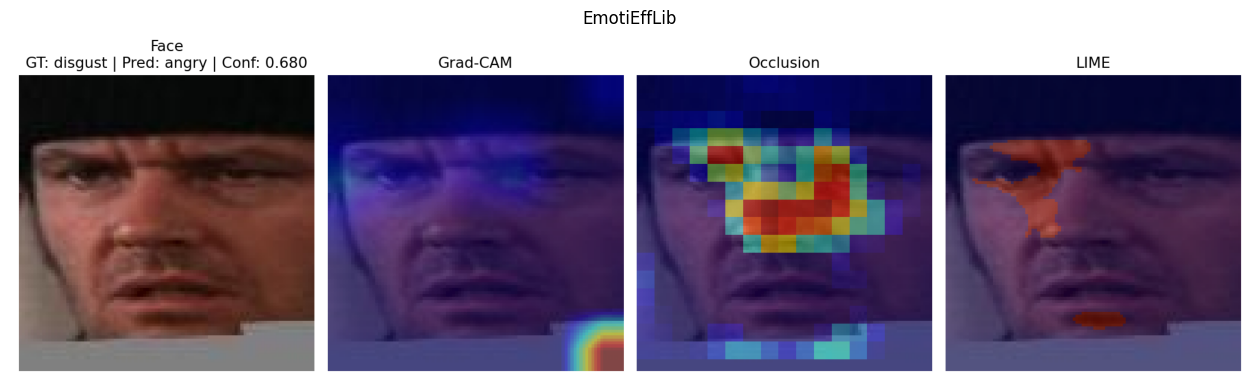

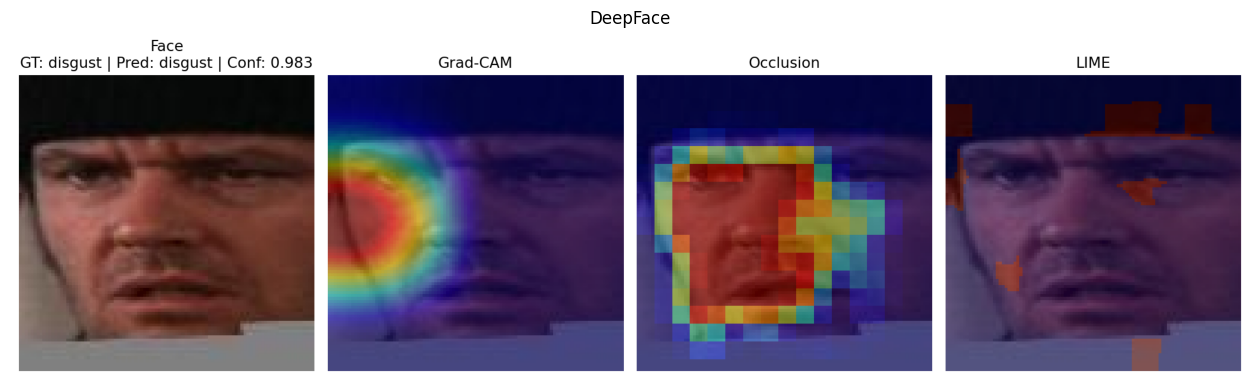

In [ ]:
# Show one saved grid from each model
emot_grids = sorted((OUT_ROOT/"emotiefflib"/"grids").glob("*.png"))
deep_grids = sorted((OUT_ROOT/"deepface"/"grids").glob("*.png"))

print("EmotiEffLib grids:", len(emot_grids))
print("DeepFace grids:", len(deep_grids))

if emot_grids:
    show_rgb(read_rgb_uint8(emot_grids[5]), title="EmotiEffLib", figsize=(16,5))
if deep_grids:
    show_rgb(read_rgb_uint8(deep_grids[5]), title="DeepFace", figsize=(16,5))


#Aggregated Grad-cam Heatmaps

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AGG_DIR = Path(OUT_ROOT) / "aggregated_gradcam"
AGG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

## Face region masks

In [ ]:
def make_region_masks(H, W):
    yy, xx = np.mgrid[0:H, 0:W]
    y = yy / (H - 1 + 1e-8)
    x = xx / (W - 1 + 1e-8)

    masks = {}
    masks["upper_face"] = (y <= 0.40)
    masks["mid_face"]   = (y > 0.40) & (y <= 0.70)
    masks["lower_face"] = (y > 0.70)

    masks["eye_band"]   = (y >= 0.18) & (y <= 0.45)
    masks["nose_band"]  = (y >= 0.45) & (y <= 0.70)
    masks["mouth_band"] = (y >= 0.70) & (y <= 0.92)

    masks["left_half"]  = (x <= 0.50)
    masks["right_half"] = (x > 0.50)

    masks["left_cheek"]  = (x >= 0.05) & (x <= 0.45) & (y >= 0.45) & (y <= 0.75)
    masks["right_cheek"] = (x >= 0.55) & (x <= 0.95) & (y >= 0.45) & (y <= 0.75)

    return masks

REGIONS = [
    "upper_face","mid_face","lower_face",
    "eye_band","nose_band","mouth_band",
    "left_cheek","right_cheek",
    "left_half","right_half"
]

def region_ratios(cam01, masks):
    cam = np.asarray(cam01, dtype=np.float32)
    overall = float(cam.mean() + 1e-8)
    out = {}
    for k, m in masks.items():
        out[k] = float(cam[m].mean() / overall)  # >1 means above-average attention
    return out

In [ ]:
def sample_indices(df_in, n=400, seed=42):
    rng = np.random.default_rng(seed)
    n = min(int(n), len(df_in))
    return rng.choice(np.arange(len(df_in)), size=n, replace=False).tolist()

IDX_AGG = sample_indices(df_eval, n=400, seed=42)  #
len(IDX_AGG)

400

In [ ]:
from tqdm import tqdm

def batch_collect_gradcam(
    df_in,
    idxs,
    model_name,
    predict_fn,      # (face_rgb) -> (probs7, pred, conf)
    gradcam_fn,      # (face_rgb) -> (cam01, overlay, heat_u8, pred, conf)
    face_crop_fn,
    detector_backend="retinaface",
    store_cams=False
):
    rows = []
    cams = [] if store_cams else None

    for i in tqdm(idxs, desc=f"{model_name}: Grad-CAM"):
        path = df_in.loc[i, "file_path"]
        gt = df_in.loc[i, "emotion_label"]
        file_name = df_in.loc[i, "file_name"] if "file_name" in df_in.columns else str(i)

        rgb = read_rgb_uint8(path)
        if rgb is None:
            continue

        face = face_crop_fn(rgb, detector_backend=detector_backend)

        # prediction (used for correctness)
        probs7, pred_p, conf_p = predict_fn(face)

        # grad-cam (canonical)
        cam01, _, _, pred_c, conf_c = gradcam_fn(face)

        pred = pred_c
        conf = float(conf_c)
        correct = bool(str(gt) == str(pred))

        H, W = cam01.shape
        masks = make_region_masks(H, W)
        rr = region_ratios(cam01, masks)

        row = {
            "model": model_name,
            "idx": int(i),
            "file_name": file_name,
            "gt": str(gt),
            "pred": str(pred),
            "conf": float(conf),
            "correct": correct,
        }
        for r in REGIONS:
            row[r] = rr[r]

        rows.append(row)

        if store_cams:
            cams.append(cam01.astype(np.float32))

    df_out = pd.DataFrame(rows)
    return df_out, cams

In [ ]:
def summarize_by(df_in, group_cols):
    out = df_in.groupby(group_cols)[REGIONS].mean().reset_index()
    return out

def melt_for_plot(summary_df, group_col):
    # converts wide region columns -> long format for plotting
    m = summary_df.melt(id_vars=[group_col], value_vars=REGIONS, var_name="region", value_name="ratio")
    return m

In [ ]:
def save_barplot(melt_df, title, out_path, group_col, order_regions=None):
    groups = list(melt_df[group_col].unique())

    n = len(groups)
    fig_h = max(3.2, 0.55 * n)
    plt.figure(figsize=(9.5, fig_h))

    # pivot to plot clean grouped bars manually (matplotlib only)
    piv = melt_df.pivot_table(index="region", columns=group_col, values="ratio", aggfunc="mean").fillna(0)

    if order_regions is not None:
        piv = piv.reindex(order_regions)

    x = np.arange(len(piv.index))
    width = 0.8 / max(1, len(groups))

    for j, g in enumerate(groups):
        plt.bar(x + (j - (len(groups)-1)/2)*width, piv[g].values, width=width, label=str(g))

    plt.xticks(x, piv.index, rotation=30, ha="right")
    plt.ylabel("Region attention ratio (mean(region)/mean(all))")
    plt.title(title)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    plt.close()

## Mean-CAM overlay

In [ ]:
def save_mean_cam_overlay(mean_cam01, out_path, title=None):
    cam = np.asarray(mean_cam01, dtype=np.float32)
    cam = np.maximum(cam, 0)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    bg = np.full((cam.shape[0], cam.shape[1], 3), 210, dtype=np.uint8)
    overlay, _ = overlay_heatmap_on_rgb(bg, cam, alpha=0.55)

    plt.figure(figsize=(4.2, 4.2))
    plt.imshow(overlay)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    plt.close()

In [ ]:
em_df, em_cams = batch_collect_gradcam(
    df_in=df_eval,
    idxs=IDX_AGG,
    model_name="emotiefflib",
    predict_fn=emotieff_predict_proba,
    gradcam_fn=emotieff_gradcam,
    face_crop_fn=get_shared_face_crop,
    store_cams=True
)

# Save raw table for transparency
em_df.to_csv(AGG_DIR / "emotiefflib_region_rows.csv", index=False)

# Mean CAM overlay (overall)
em_mean_cam = np.mean(np.stack(em_cams, axis=0), axis=0)
save_mean_cam_overlay(em_mean_cam, AGG_DIR / "emotiefflib_mean_cam_overall.png", title="EmotiEffLib Mean Grad-CAM")

emotiefflib: Grad-CAM: 100%|██████████| 400/400 [04:30<00:00,  1.48it/s]


## Barplots

In [ ]:
# By GT emotion
em_gt = summarize_by(em_df, ["gt"])
em_gt_m = melt_for_plot(em_gt, "gt")
save_barplot(
    em_gt_m,
    title="EmotiEffLib — Region Attention by Ground Truth",
    out_path=AGG_DIR / "emotiefflib_region_by_gt.png",
    group_col="gt",
    order_regions=REGIONS
)

# Correct vs Incorrect
em_cor = summarize_by(em_df, ["correct"])
em_cor_m = melt_for_plot(em_cor, "correct")
# make labels nicer
em_cor_m["correct"] = em_cor_m["correct"].map({True:"Correct", False:"Incorrect"})
save_barplot(
    em_cor_m,
    title="EmotiEffLib — Region Attention (Correct vs Incorrect)",
    out_path=AGG_DIR / "emotiefflib_region_correct_vs_incorrect.png",
    group_col="correct",
    order_regions=REGIONS
)


## DeepFace aggregated CAM

In [ ]:
df_df, df_cams = batch_collect_gradcam(
    df_in=df_eval,
    idxs=IDX_AGG,
    model_name="deepface",
    predict_fn=deepface_predict_proba,
    gradcam_fn=deepface_gradcam,
    face_crop_fn=get_shared_face_crop,
    store_cams=True
)

df_df.to_csv(AGG_DIR / "deepface_region_rows.csv", index=False)

df_mean_cam = np.mean(np.stack(df_cams, axis=0), axis=0)
save_mean_cam_overlay(df_mean_cam, AGG_DIR / "deepface_mean_cam_overall.png", title="DeepFace Mean Grad-CAM")

deepface: Grad-CAM: 100%|██████████| 400/400 [05:12<00:00,  1.28it/s]


## DeepFace barplots

In [ ]:
df_gt = summarize_by(df_df, ["gt"])
df_gt_m = melt_for_plot(df_gt, "gt")
save_barplot(
    df_gt_m,
    title="DeepFace — Region Attention by Ground Truth",
    out_path=AGG_DIR / "deepface_region_by_gt.png",
    group_col="gt",
    order_regions=REGIONS
)

df_cor = summarize_by(df_df, ["correct"])
df_cor_m = melt_for_plot(df_cor, "correct")
df_cor_m["correct"] = df_cor_m["correct"].map({True:"Correct", False:"Incorrect"})
save_barplot(
    df_cor_m,
    title="DeepFace — Region Attention (Correct vs Incorrect)",
    out_path=AGG_DIR / "deepface_region_correct_vs_incorrect.png",
    group_col="correct",
    order_regions=REGIONS
)

# Per-Emotion Mean Cam

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

MEAN_DIR = Path(OUT_ROOT) / "mean_cam_by_gt"
MEAN_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 160,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

In [ ]:
def sample_idxs_per_emotion(df_in, n_per_class=120, seed=42):
    rng = np.random.default_rng(seed)
    idxs_by = {}
    for emo in EMOTIONS:
        sub = df_in[df_in["emotion_label"] == emo]
        if len(sub) == 0:
            idxs_by[emo] = []
            continue
        take = min(int(n_per_class), len(sub))
        idxs_by[emo] = rng.choice(sub.index.values, size=take, replace=False).tolist()
    return idxs_by

# You can raise this (e.g., 300) if runtime allows.
IDXS_BY_GT = sample_idxs_per_emotion(df_eval, n_per_class=120, seed=42)

{k: len(v) for k, v in IDXS_BY_GT.items()}


{'angry': 120,
 'disgust': 120,
 'fear': 74,
 'happy': 120,
 'sad': 120,
 'surprise': 120,
 'neutral': 120}

In [ ]:
from tqdm import tqdm
import cv2

def compute_mean_cam_by_gt(
    df_in,
    idxs_by_gt,
    model_name,
    gradcam_fn,           # returns (cam01, overlay, heat_u8, pred, conf)
    face_crop_fn,
    out_dir: Path,
    detector_backend="retinaface"
):
    model_dir = out_dir / model_name
    (model_dir / "single").mkdir(parents=True, exist_ok=True)
    (model_dir / "grid").mkdir(parents=True, exist_ok=True)

    mean_cams = {}
    counts = {}

    # neutral background for consistent overlays
    def save_overlay(cam01, save_path, title=None):
        cam = np.asarray(cam01, dtype=np.float32)
        cam = np.maximum(cam, 0)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        bg = np.full((cam.shape[0], cam.shape[1], 3), 210, dtype=np.uint8)
        overlay, _ = overlay_heatmap_on_rgb(bg, cam, alpha=0.55)

        plt.figure(figsize=(4.2, 4.2))
        plt.imshow(overlay)
        plt.axis("off")
        if title:
            plt.title(title)
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches="tight")
        plt.close()

    for gt_emo in EMOTIONS:
        idxs = idxs_by_gt.get(gt_emo, [])
        if len(idxs) == 0:
            mean_cams[gt_emo] = None
            counts[gt_emo] = 0
            continue

        cams = []
        for i in tqdm(idxs, desc=f"{model_name}: mean CAM for GT={gt_emo}"):
            path = df_in.loc[i, "file_path"]
            rgb = read_rgb_uint8(path)
            if rgb is None:
                continue

            face = face_crop_fn(rgb, detector_backend=detector_backend)

            try:
                cam01, _, _, _, _ = gradcam_fn(face)
                cams.append(cam01.astype(np.float32))
            except Exception:
                # skip failures silently to keep outputs clean
                continue

        if len(cams) == 0:
            mean_cams[gt_emo] = None
            counts[gt_emo] = 0
            continue

        mean_cam = np.mean(np.stack(cams, axis=0), axis=0).astype(np.float32)
        mean_cams[gt_emo] = mean_cam
        counts[gt_emo] = len(cams)

        # save single overlay
        save_overlay(
            mean_cam,
            model_dir / "single" / f"{model_name}_meanCAM_GT-{gt_emo}_n{len(cams)}.png",
            title=f"{model_name} — GT={gt_emo} (n={len(cams)})"
        )

    return mean_cams, counts, model_dir

In [ ]:
def save_7panel_grid(mean_cams, counts, model_name, model_dir: Path):
    # background for overlays
    def overlay_on_bg(cam01):
        cam = np.asarray(cam01, dtype=np.float32)
        cam = np.maximum(cam, 0)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        bg = np.full((cam.shape[0], cam.shape[1], 3), 210, dtype=np.uint8)
        overlay, _ = overlay_heatmap_on_rgb(bg, cam, alpha=0.55)
        return overlay

    # pick a reference shape from first available cam
    ref = None
    for e in EMOTIONS:
        if mean_cams.get(e) is not None:
            ref = mean_cams[e]
            break
    if ref is None:
        raise RuntimeError(f"No mean CAMs available for {model_name}")

    fig = plt.figure(figsize=(14, 4.2))
    for j, emo in enumerate(EMOTIONS):
        ax = plt.subplot(1, 7, j + 1)
        cam = mean_cams.get(emo)
        if cam is None:
            ax.text(0.5, 0.5, f"{emo}\n(n=0)", ha="center", va="center")
            ax.axis("off")
            continue

        overlay = overlay_on_bg(cam)
        ax.imshow(overlay)
        ax.axis("off")
        ax.set_title(f"{emo}\n(n={counts.get(emo,0)})")

    plt.tight_layout()
    out_path = model_dir / "grid" / f"{model_name}_meanCAM_7panel_byGT.png"
    plt.savefig(out_path, bbox_inches="tight")
    plt.close()
    return out_path


## EmotiEffLib

In [ ]:
em_mean_cams, em_counts, em_dir = compute_mean_cam_by_gt(
    df_in=df_eval,
    idxs_by_gt=IDXS_BY_GT,
    model_name="emotiefflib",
    gradcam_fn=emotieff_gradcam,
    face_crop_fn=get_shared_face_crop,
    out_dir=MEAN_DIR
)

em_grid_path = save_7panel_grid(em_mean_cams, em_counts, "emotiefflib", em_dir)
em_grid_path

emotiefflib: mean CAM for GT=neutral: 100%|██████████| 120/120 [01:21<00:00,  1.47it/s]


PosixPath('/content/protocolA_outputs/mean_cam_by_gt/emotiefflib/grid/emotiefflib_meanCAM_7panel_byGT.png')

## DeepFace

In [ ]:
df_mean_cams, df_counts, df_dir = compute_mean_cam_by_gt(
    df_in=df_eval,
    idxs_by_gt=IDXS_BY_GT,
    model_name="deepface",
    gradcam_fn=deepface_gradcam,
    face_crop_fn=get_shared_face_crop,
    out_dir=MEAN_DIR
)

df_grid_path = save_7panel_grid(df_mean_cams, df_counts, "deepface", df_dir)
df_grid_path

deepface: mean CAM for GT=neutral: 100%|██████████| 120/120 [01:21<00:00,  1.47it/s]


PosixPath('/content/protocolA_outputs/mean_cam_by_gt/deepface/grid/deepface_meanCAM_7panel_byGT.png')

### Display grids

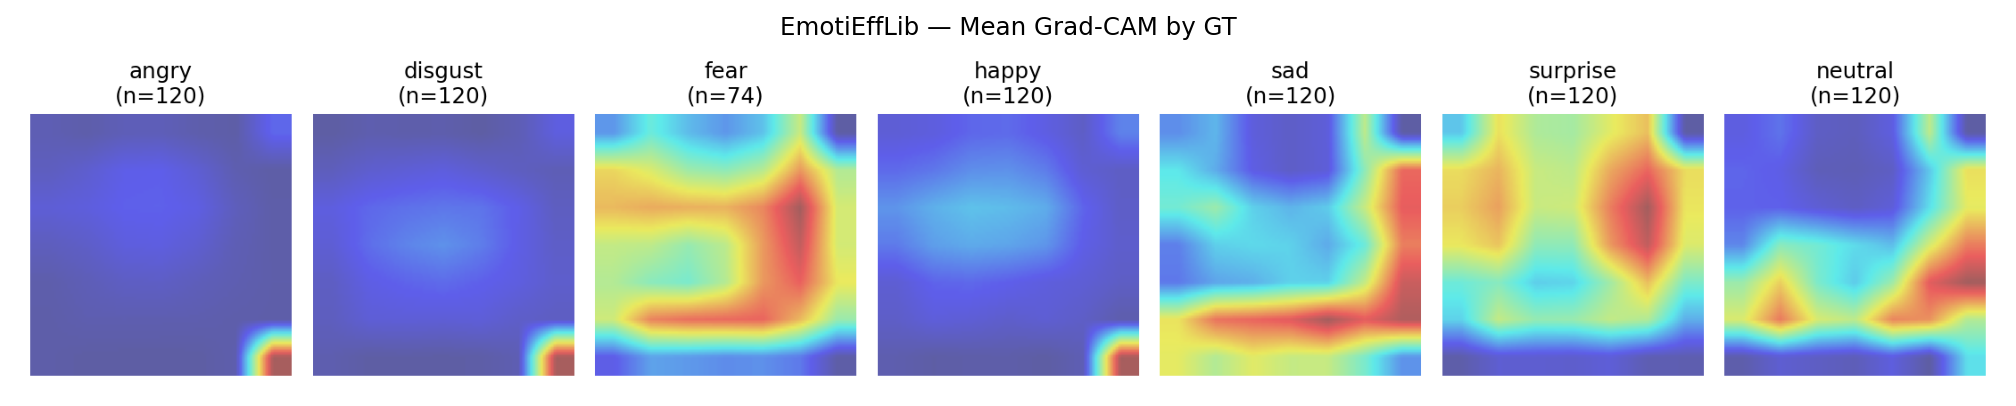

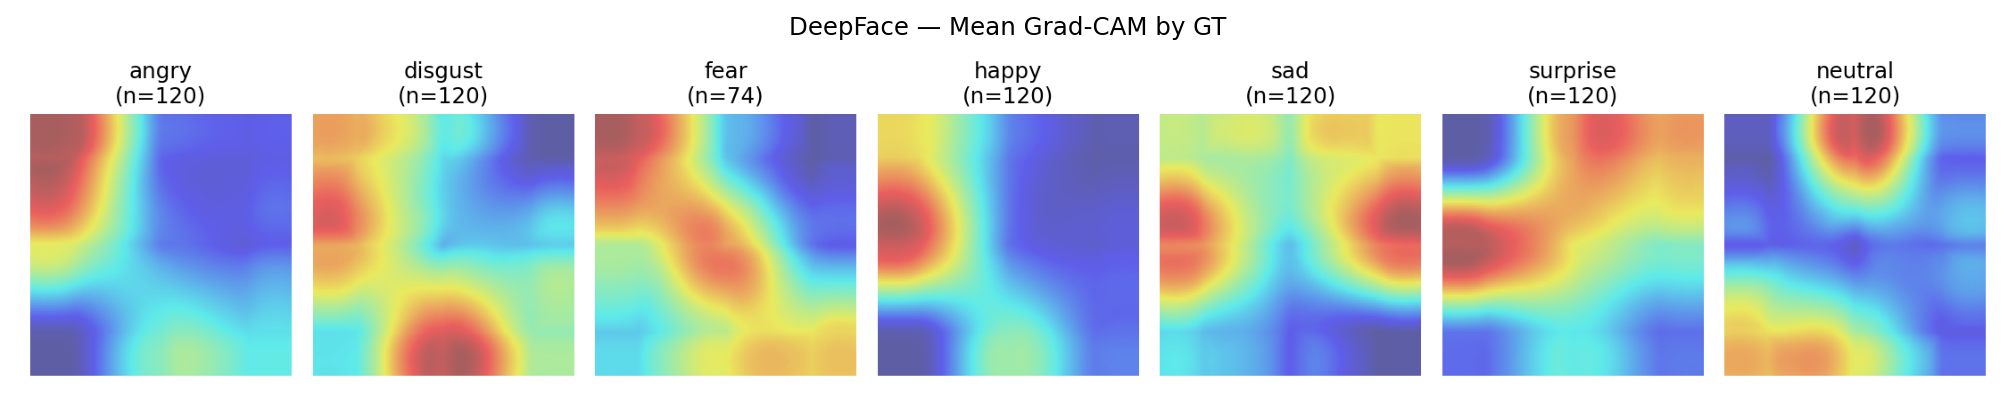

In [ ]:
show_rgb(read_rgb_uint8(em_grid_path), title="EmotiEffLib — Mean Grad-CAM by GT", figsize=(16,5))
show_rgb(read_rgb_uint8(df_grid_path), title="DeepFace — Mean Grad-CAM by GT", figsize=(16,5))

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

def show_saved(path, title=None, figsize=(10,4)):
    img = Image.open(path)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()

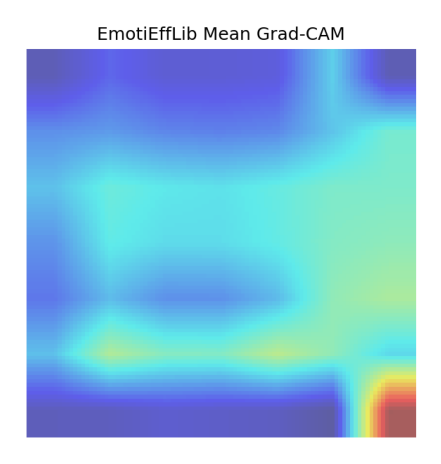

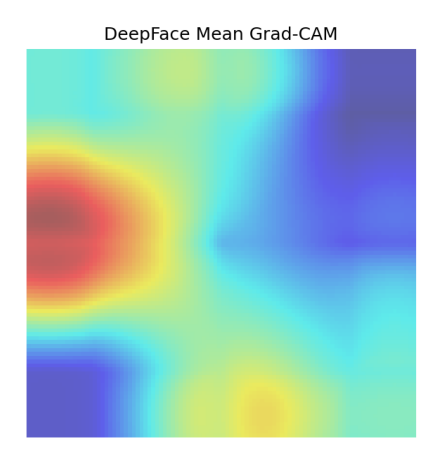

In [ ]:
show_saved(
    OUT_ROOT / "aggregated_gradcam" / "emotiefflib_mean_cam_overall.png",
    #title="EmotiEffLib — Overall Mean Grad-CAM",
    figsize=(3,3)
)

show_saved(
    OUT_ROOT / "aggregated_gradcam" / "deepface_mean_cam_overall.png",
    #title="DeepFace — Overall Mean Grad-CAM",
    figsize=(3,3)
)

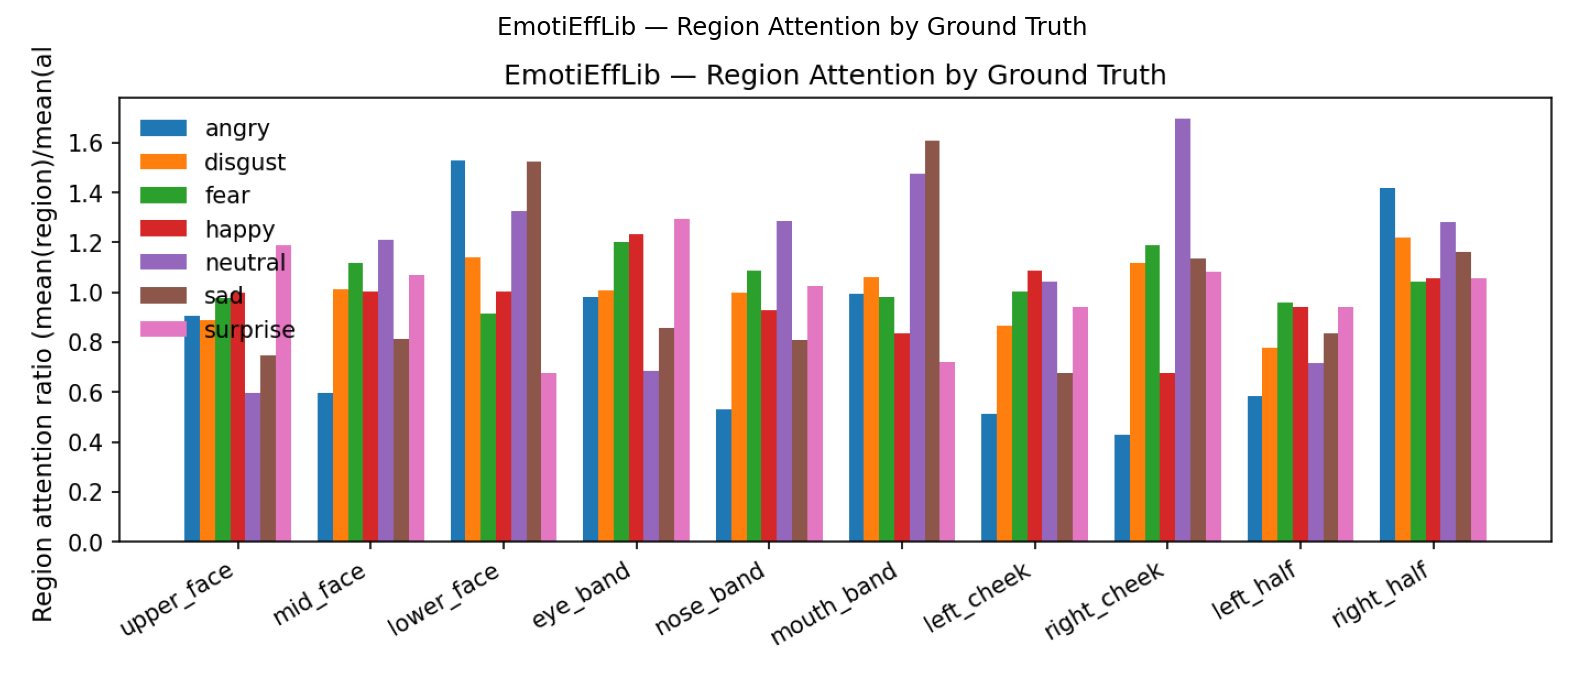

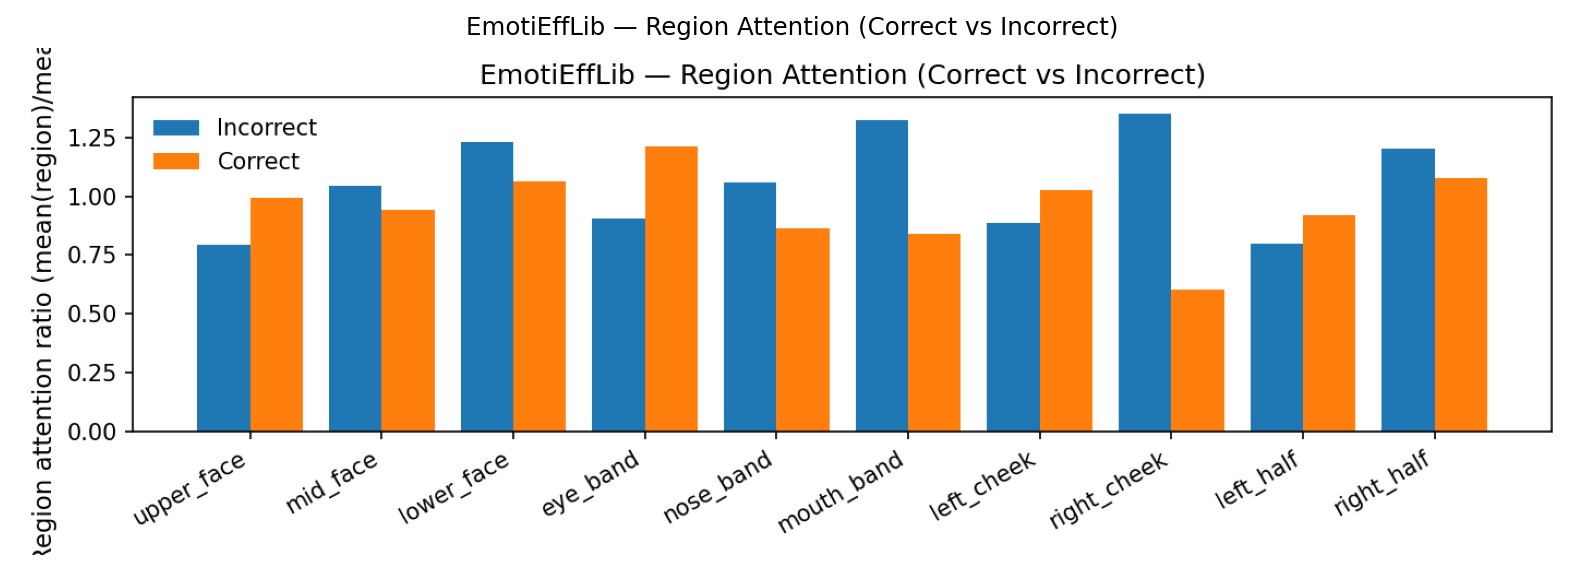

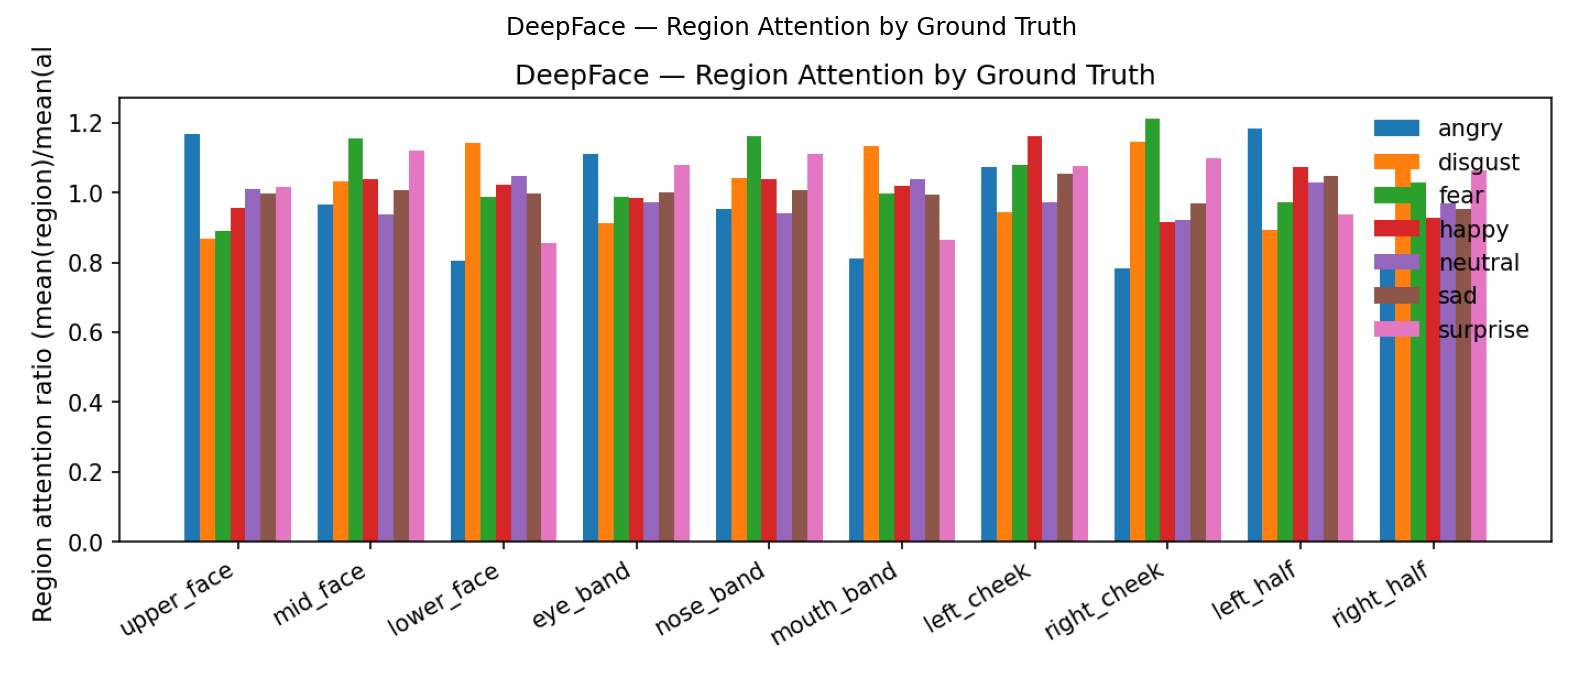

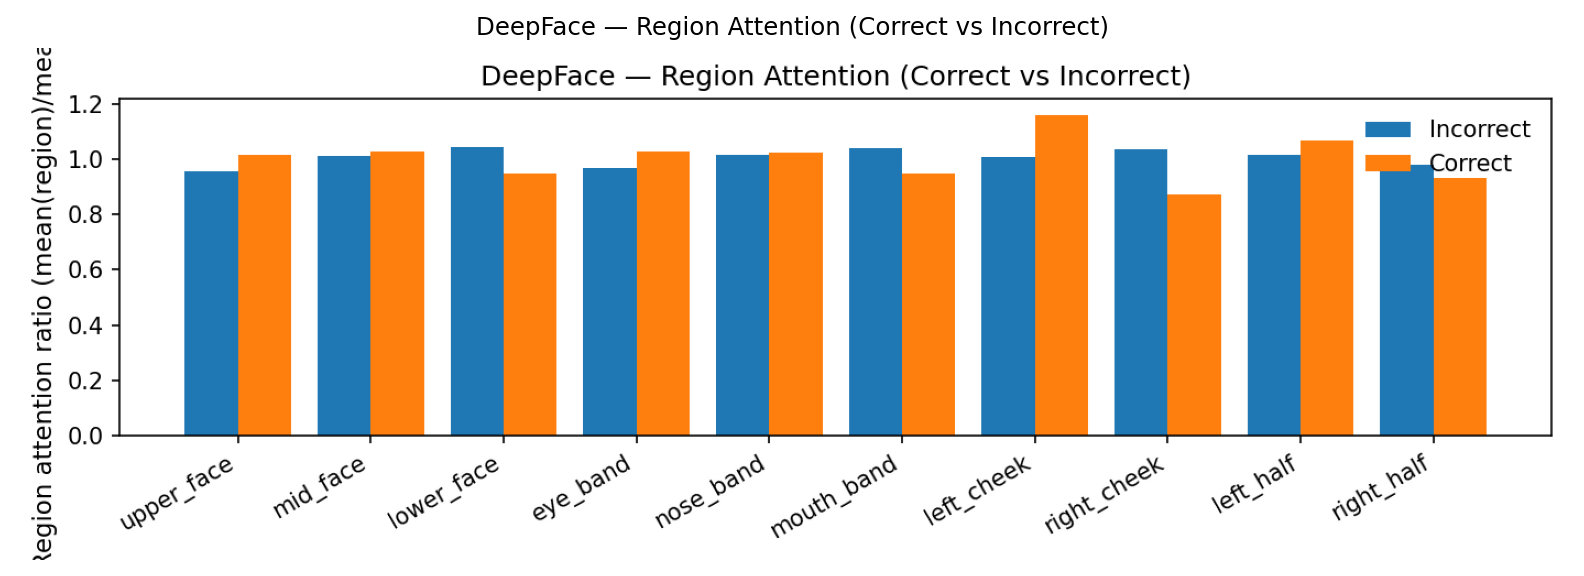

In [ ]:
show_saved(
    OUT_ROOT / "aggregated_gradcam" / "emotiefflib_region_by_gt.png",
    title="EmotiEffLib — Region Attention by Ground Truth",
    figsize=(10,5)
)

show_saved(
    OUT_ROOT / "aggregated_gradcam" / "emotiefflib_region_correct_vs_incorrect.png",
    title="EmotiEffLib — Region Attention (Correct vs Incorrect)",
    figsize=(10,5)
)

show_saved(
    OUT_ROOT / "aggregated_gradcam" / "deepface_region_by_gt.png",
    title="DeepFace — Region Attention by Ground Truth",
    figsize=(10,5)
)

show_saved(
    OUT_ROOT / "aggregated_gradcam" / "deepface_region_correct_vs_incorrect.png",
    title="DeepFace — Region Attention (Correct vs Incorrect)",
    figsize=(10,5)
)

Saved files

In [ ]:
print("EmotiEffLib singles:", len(list((em_dir/"single").glob("*.png"))))
print("DeepFace singles:", len(list((df_dir/"single").glob("*.png"))))

sorted([p.name for p in (em_dir/"single").glob("*.png")])[:5], sorted([p.name for p in (df_dir/"single").glob("*.png")])[:5]

EmotiEffLib singles: 7
DeepFace singles: 7


(['emotiefflib_meanCAM_GT-angry_n120.png',
  'emotiefflib_meanCAM_GT-disgust_n120.png',
  'emotiefflib_meanCAM_GT-fear_n74.png',
  'emotiefflib_meanCAM_GT-happy_n120.png',
  'emotiefflib_meanCAM_GT-neutral_n120.png'],
 ['deepface_meanCAM_GT-angry_n120.png',
  'deepface_meanCAM_GT-disgust_n120.png',
  'deepface_meanCAM_GT-fear_n74.png',
  'deepface_meanCAM_GT-happy_n120.png',
  'deepface_meanCAM_GT-neutral_n120.png'])

# References

[1] R. R. Selvaraju, M. Cogswell, A. Das, R. Vedantam, D. Parikh, and D. Batra,  
“Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization,”  
in *Proc. IEEE Int. Conf. Computer Vision (ICCV)*, 2017.  
Available: https://openaccess.thecvf.com/content_ICCV_2017/papers/Selvaraju_Grad-CAM_Visual_Explanations_ICCV_2017_paper.pdf

[2] S. Li, W. Deng, and J. Du,  
“Reliable Crowdsourcing and Deep Locality-Preserving Learning for Expression Recognition in the Wild,”  
in *Proc. IEEE Conf. Computer Vision and Pattern Recognition (CVPR)*, 2017, pp. 2584–2593.  
(Original RAF-DB paper)  
Available: https://openaccess.thecvf.com/content_cvpr_2017/papers/Li_Reliable_Crowdsourcing_and_CVPR_2017_paper.pdf

[3] E. Barsoum, C. Zhang, C. Canton Ferrer, and Z. Zhang,  
“Training Deep Networks for Facial Expression Recognition with Crowd-Sourced Label Distribution,”  
in *Proc. 18th ACM Int. Conf. on Multimodal Interaction (ICMI)*, 2016.  
(Original FER+ paper)  
Preprint available: https://arxiv.org/abs/1608.01041

[4] Microsoft,  
“FER+: New Label Annotations for the FER2013 Dataset,”  
GitHub repository, 2016–.  
Available: https://github.com/microsoft/FERPlus

[5] S. Li, W. Deng,  
“Real-world Affective Faces Database (RAF-DB),”  
Dataset website, Beijing University of Posts and Telecommunications.  
Available: http://www.whdeng.cn/RAF/model1.html

[6] S. Serengil and A. Ozpinar,  
“DeepFace: A Lightweight Face Recognition and Facial Attribute Analysis (Age, Gender, Emotion and Race) Library for Python,”  
GitHub repository, 2017–.  
Available: https://github.com/serengil/deepface

[7] C. Guo, G. Pleiss, Y. Sun, and K. Q. Weinberger,  
“On Calibration of Modern Neural Networks,”  
in *Proc. 34th Int. Conf. on Machine Learning (ICML)*, 2017.  
(Defines Expected Calibration Error and reliability diagrams.)  
Available: https://proceedings.mlr.press/v70/guo17a/guo17a.pdf

[8] Z. Lian, Y. Li, J.-H. Tao, J. Huang, and M.-Y. Niu,  
“Expression Analysis Based on Face Regions in Real-world Conditions,”  
arXiv preprint, 2019.  
(Analyzes contribution of different face areas to different emotions, using CAM/Grad-CAM.)  
Available: https://arxiv.org/abs/1911.05188

[9] K. Kärkkäinen and J. Joo,  
“FairFace: Face Attribute Dataset for Balanced Race, Gender, and Age,”  
in *Proc. IEEE/CVF Winter Conf. on Applications of Computer Vision (WACV)*, 2021.  
Available: https://openaccess.thecvf.com/content/WACV2021/papers/Karkkainen_FairFace_Face_Attribute_Dataset_for_Balanced_Race_Gender_and_Age_WACV_2021_paper.pdf  
Dataset GitHub: https://github.com/joojs/fairface

[10] C. T. Keating and co-authors,  
“Facial Expression Production and Recognition in Autism Spectrum Disorders,”  
in *Child and Adolescent Psychiatric Clinics of North America*, vol. 29, no. 3, 2020, pp. 557–573.  
(Review on facial expression production/recognition in autism.)  
Available: https://www.childpsych.theclinics.com/article/S1056-4993(20)30018-3/fulltext

[11] High-Level Expert Group on Artificial Intelligence, European Commission,  
“Ethics Guidelines for Trustworthy AI,” 2019.  
Available: https://digital-strategy.ec.europa.eu/en/library/ethics-guidelines-trustworthy-ai


Authored by

*   Hassen Said Ali

*   Luwam Major Kefali
*   Hilina Fissha Woreta
